In [1]:
import re
import nltk
import pandas as pd
import matplotlib

In [2]:
df = pd.read_csv('../data/tripadvisor_hotel_reviews.csv')

In [3]:
df.head()

,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


#### text preprocessing

##### convert to lower case

In [4]:
reviews = df['Review'].str.lower() # since only 1 column is returned, reviews becomes a pandas series

print(reviews)

0      nice hotel expensive parking got good deal sta...
1      ok nothing special charge diamond member hilto...
2      nice rooms not 4* experience hotel monaco seat...
3      unique, great stay, wonderful time hotel monac...
4      great stay great stay, went seahawk game aweso...
                             ...                        
104    fairmont hotel singapore splendid, stayed fair...
105    great hotel stayed hotel night route perth chr...
106    great hotel centre stayed 5 nights room overlo...
107    great location great value great hotel husband...
108    lovely hotel great location stayed vacation to...
Name: Review, Length: 109, dtype: str


##### handle special characters

In [5]:
reviews = reviews.apply(lambda row: re.sub(r'([*])', r'star', row)) # 4* to 4star

reviews = reviews.apply(lambda row: re.sub(r'[^\w\s]', '', row)) # remove everything except alphanumerics(\w) and spaces(\s)

print(reviews)

0      nice hotel expensive parking got good deal sta...
1      ok nothing special charge diamond member hilto...
2      nice rooms not 4star experience hotel monaco s...
3      unique great stay wonderful time hotel monaco ...
4      great stay great stay went seahawk game awesom...
                             ...                        
104    fairmont hotel singapore splendid stayed fairm...
105    great hotel stayed hotel night route perth chr...
106    great hotel centre stayed 5 nights room overlo...
107    great location great value great hotel husband...
108    lovely hotel great location stayed vacation to...
Name: Review, Length: 109, dtype: str


##### tokenize

In [6]:
from nltk import word_tokenize
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\anshu\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [7]:
reviews = reviews.apply(lambda row: word_tokenize(row))

print(reviews)

0      [nice, hotel, expensive, parking, got, good, d...
1      [ok, nothing, special, charge, diamond, member...
2      [nice, rooms, not, 4star, experience, hotel, m...
3      [unique, great, stay, wonderful, time, hotel, ...
4      [great, stay, great, stay, went, seahawk, game...
                             ...                        
104    [fairmont, hotel, singapore, splendid, stayed,...
105    [great, hotel, stayed, hotel, night, route, pe...
106    [great, hotel, centre, stayed, 5, nights, room...
107    [great, location, great, value, great, hotel, ...
108    [lovely, hotel, great, location, stayed, vacat...
Name: Review, Length: 109, dtype: object


##### remove stopwords

In [8]:
from nltk.corpus import stopwords
nltk.download('stopwords')

en_stopwords = stopwords.words('english')
en_stopwords.remove('not')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\anshu\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [9]:
reviews = reviews.apply(lambda row: [word for word in row if word not in en_stopwords])

print(reviews)

0      [nice, hotel, expensive, parking, got, good, d...
1      [ok, nothing, special, charge, diamond, member...
2      [nice, rooms, not, 4star, experience, hotel, m...
3      [unique, great, stay, wonderful, time, hotel, ...
4      [great, stay, great, stay, went, seahawk, game...
                             ...                        
104    [fairmont, hotel, singapore, splendid, stayed,...
105    [great, hotel, stayed, hotel, night, route, pe...
106    [great, hotel, centre, stayed, 5, nights, room...
107    [great, location, great, value, great, hotel, ...
108    [lovely, hotel, great, location, stayed, vacat...
Name: Review, Length: 109, dtype: object


##### stemming / lemmatization

> lemmatization is slower but often better than stemming

In [10]:
from nltk import PorterStemmer, WordNetLemmatizer

nltk.download('wordnet') # dictionary

ps = PorterStemmer()
lz = WordNetLemmatizer()

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\anshu\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [11]:
# reviews = reviews.apply(lambda row: [ps.stem(word) for word in row])
reviews = reviews.apply(lambda row: [lz.lemmatize(word) for word in row])

print(reviews)

0      [nice, hotel, expensive, parking, got, good, d...
1      [ok, nothing, special, charge, diamond, member...
2      [nice, room, not, 4star, experience, hotel, mo...
3      [unique, great, stay, wonderful, time, hotel, ...
4      [great, stay, great, stay, went, seahawk, game...
                             ...                        
104    [fairmont, hotel, singapore, splendid, stayed,...
105    [great, hotel, stayed, hotel, night, route, pe...
106    [great, hotel, centre, stayed, 5, night, room,...
107    [great, location, great, value, great, hotel, ...
108    [lovely, hotel, great, location, stayed, vacat...
Name: Review, Length: 109, dtype: object


#### n-gram

In [12]:
all_tokens = sum(reviews, []) # create one big list from all the small lists

##### unigram

In [13]:
unigrams = pd.Series(all_tokens).value_counts()

<Axes: >

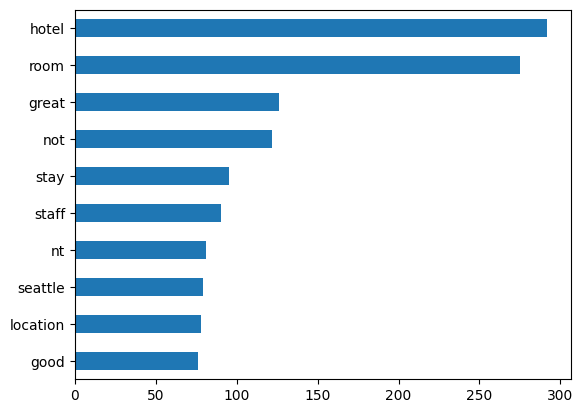

In [14]:
unigrams.head(10).sort_values().plot.barh()

##### bigram

In [15]:
bigrams = list(nltk.ngrams(all_tokens, 2)) # list of bigrams [(word1, word2), (word2, word3), ...]

bigrams = pd.Series(bigrams).value_counts()

<Axes: >

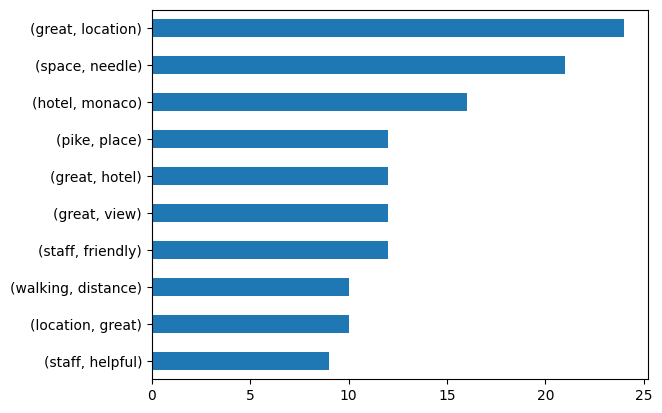

In [16]:
bigrams.head(10).sort_values().plot.barh()